In [44]:
#Imports
from tensorflow.keras.datasets import cifar10
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [46]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [47]:
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


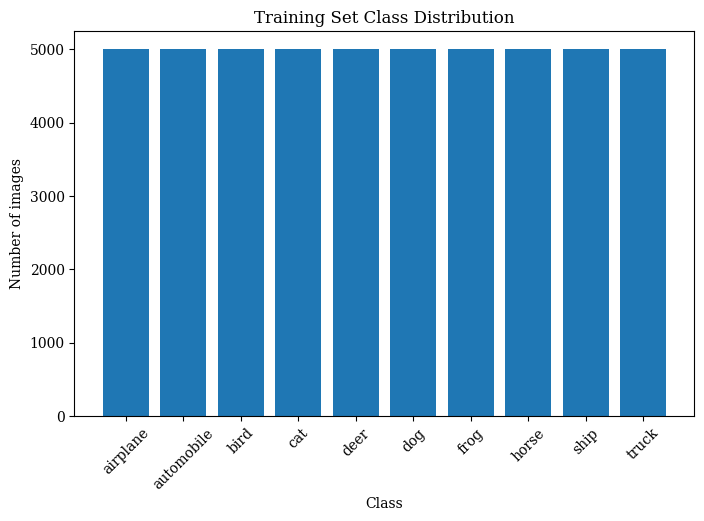

In [48]:
#Flatten the data
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

#Balanced Data or Not
classes, counts = np.unique(y_train_flat, return_counts=True)

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("Training Set Class Distribution")
plt.xticks(rotation=45)
plt.show()

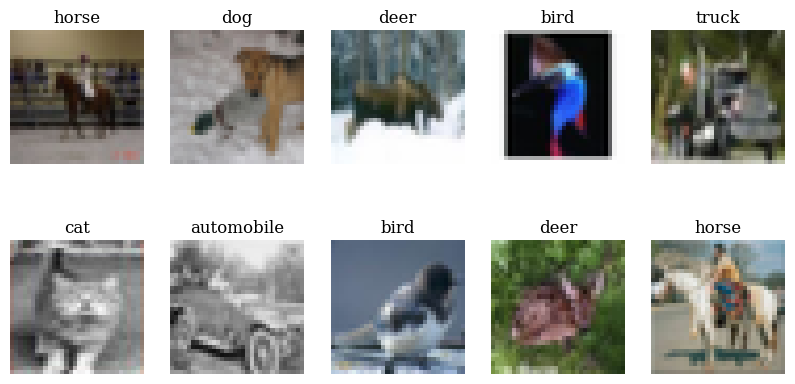

In [49]:
plt.figure(figsize=(10,5))

rand = np.random.randint(0, 50000, 10)

for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.imshow(x_train[rand[i]])
  plt.title(class_names[y_train[rand[i]][0]])
  plt.axis("off")
plt.show()

In [50]:
#Convert to one hot labels
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


Training with optimizer=adam, batch_size=32

Training with optimizer=adam, batch_size=128

Training with optimizer=sgd, batch_size=32

Training with optimizer=sgd, batch_size=128
  optimizer  batch_size  final_train_acc  final_val_acc  final_val_loss
0      adam          32         0.697911         0.7288        0.786677
1      adam         128         0.604978         0.6740        0.929300
2       sgd          32         0.483978         0.5064        1.367417
3       sgd         128         0.313800         0.3544        1.826775


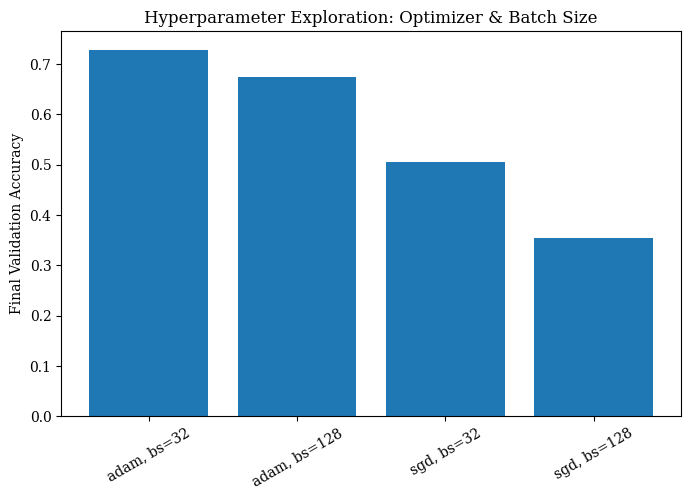

In [51]:
#Hyperparameter Exploration
import pandas as pd

def build_model():
    return Sequential([
        Input(shape=(32, 32, 3)),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(10, activation="softmax")
    ])

optimizers = ["adam", "sgd"]
batch_sizes = [32, 128]
EXPLORE_EPOCHS = 5

results = []
for opt in optimizers:
    for bs in batch_sizes:
        print(f"\nTraining with optimizer={opt}, batch_size={bs}")
        m = build_model()
        m.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
        h = m.fit(x_train, y_train_onehot, batch_size=bs, epochs=EXPLORE_EPOCHS,
                  validation_split=0.1, verbose=0)
        results.append({
            "optimizer": opt, "batch_size": bs,
            "final_train_acc": h.history["accuracy"][-1],
            "final_val_acc": h.history["val_accuracy"][-1],
            "final_val_loss": h.history["val_loss"][-1]
        })

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 5))
labels = [f"{r['optimizer']}, bs={r['batch_size']}" for r in results]
plt.bar(labels, results_df["final_val_acc"])
plt.ylabel("Final Validation Accuracy")
plt.title("Hyperparameter Exploration: Optimizer & Batch Size")
plt.xticks(rotation=30)
plt.show()

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3981 - loss: 1.6357 - val_accuracy: 0.5686 - val_loss: 1.2007
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.5650 - loss: 1.2170 - val_accuracy: 0.6268 - val_loss: 1.0850
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6383 - loss: 1.0381 - val_accuracy: 0.6936 - val_loss: 0.8816
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6824 - loss: 0.9198 - val_accuracy: 0.7228 - val_loss: 0.8169
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7108 - loss: 0.8432 - val_accuracy: 0.7162 - val_loss: 0.8294
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7290 - loss: 0.7793 - val_accuracy: 0.7482 - val_loss: 0.7402
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7508 - loss: 0.7231 - val_accuracy: 0.7436 - val_loss: 0.7548
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7651 - loss: 0.6722 

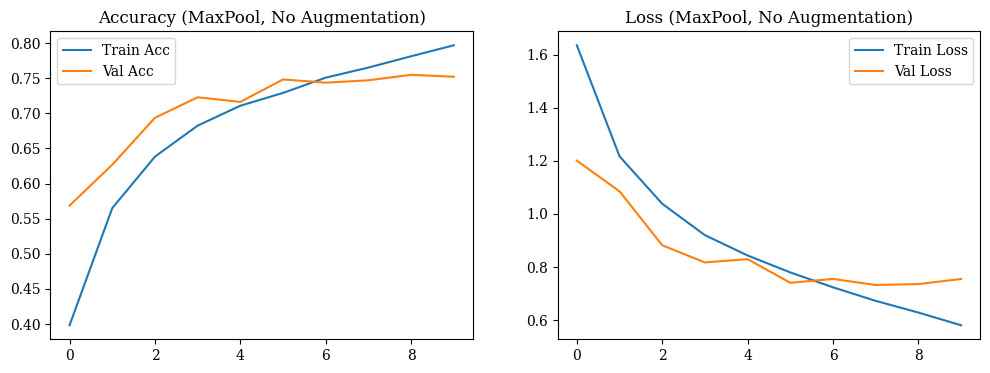

In [52]:
#Max Pool No Data Aug Model
model_maxpool_no_aug = Sequential([
        Input(shape=(32, 32, 3)),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.5),
        Dense(10, activation="softmax")
    ])

model_maxpool_no_aug.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_maxpool_no_aug = model_maxpool_no_aug.fit(
    x_train, y_train_onehot,
    batch_size=32,
    epochs=10,
    validation_split=0.1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_maxpool_no_aug.history["accuracy"], label="Train Acc")
plt.plot(history_maxpool_no_aug.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy (MaxPool, No Augmentation)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_maxpool_no_aug.history["loss"], label="Train Loss")
plt.plot(history_maxpool_no_aug.history["val_loss"], label="Val Loss")
plt.title("Loss (MaxPool, No Augmentation)")
plt.legend()
plt.show()

In [53]:
#Max Pool + Data Aug Model
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
], name="data_augmentation")

model = Sequential([
    Input(shape=(32, 32, 3)),
    data_augmentation,

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history = model.fit(x_train, y_train_onehot, batch_size=32, epochs=10, validation_split=0.1)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.3518 - loss: 1.7669 - val_accuracy: 0.4414 - val_loss: 1.5571
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4696 - loss: 1.4803 - val_accuracy: 0.5554 - val_loss: 1.2935
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5138 - loss: 1.3638 - val_accuracy: 0.5834 - val_loss: 1.1882
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5429 - loss: 1.2913 - val_accuracy: 0.6140 - val_loss: 1.0924
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5670 - loss: 1.2315 - val_accuracy: 0.6292 - val_loss: 1.0485
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5811 - loss: 1.1913 - val_accuracy: 0.6378 - val_loss: 1.0521
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.5979 - loss: 1.1507 - val_accuracy: 0.6616 - val_loss: 0.9595
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.6082 - loss: 1

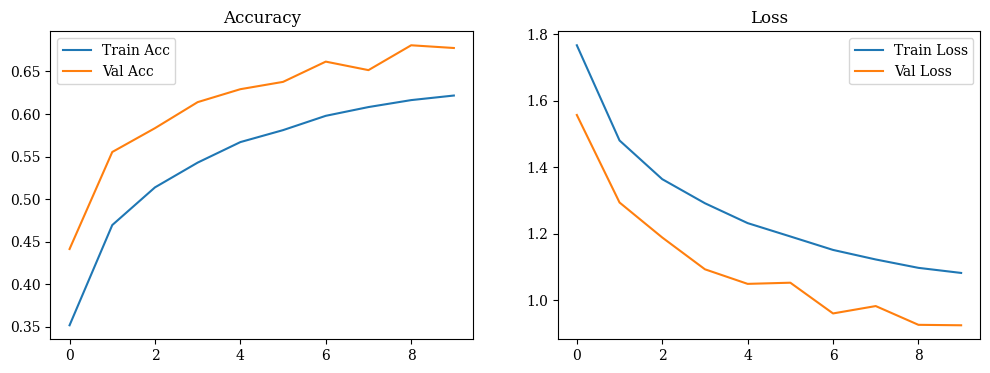

In [55]:
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== Summary Metrics ===
Accuracy : 0.6690
Precision: 0.6727
Recall   : 0.6690
F1-Score : 0.6572

              precision    recall  f1-score   support

    airplane       0.69      0.72      0.71      1000
  automobile       0.73      0.88      0.80      1000
        bird       0.77      0.33      0.46      1000
         cat       0.52      0.44      0.48      1000
        deer       0.62      0.56      0.59      1000
         dog       0.65      0.53      0.58      1000
        frog       0.59      0.85      0.70      1000
       horse       0.68      0.79      0.73      1000
        ship       0.79      0.82      0.80      1000
       truck       0.69      0.78      0.73      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.66     10000
weighted avg       0.67      0.67      0.66     10000



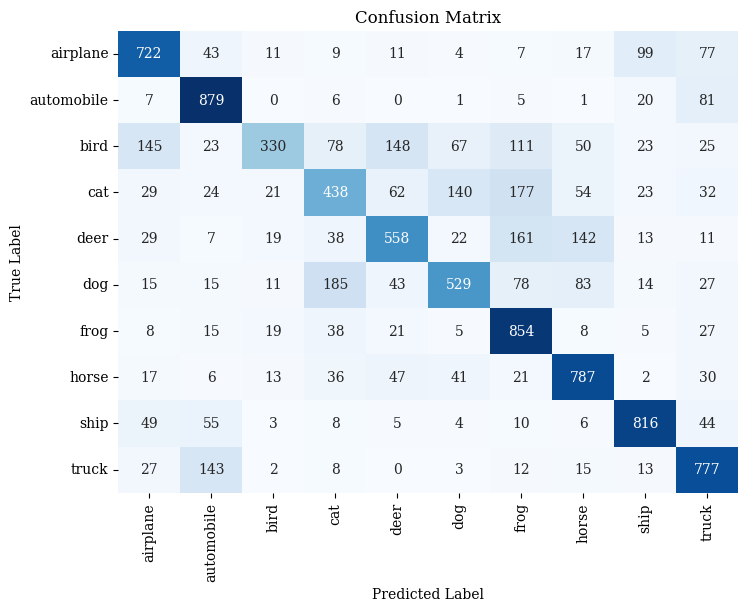

In [56]:
y_pred_probs = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

acc = accuracy_score(y_test, y_pred_classes)
precision = precision_score(y_test, y_pred_classes, average="macro")
recall = recall_score(y_test, y_pred_classes, average="macro")
f1 = f1_score(y_test, y_pred_classes, average="macro")

print("=== Summary Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")

#Classification Report
print(classification_report(y_test, y_pred_classes,target_names=class_names))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3638 - loss: 1.7260 - val_accuracy: 0.4812 - val_loss: 1.4399
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5036 - loss: 1.3758 - val_accuracy: 0.5846 - val_loss: 1.1649
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5638 - loss: 1.2281 - val_accuracy: 0.6428 - val_loss: 1.0279
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6032 - loss: 1.1259 - val_accuracy: 0.6720 - val_loss: 0.9403
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6328 - loss: 1.0405 - val_accuracy: 0.6878 - val_loss: 0.9001
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.6588 - loss: 0.9733 - val_accuracy: 0.6984 - val_loss: 0.8719
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6820 - loss: 0.9097 - val_accuracy: 0.6958 - val_loss: 0.8816
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6973 - loss: 0.8635 -

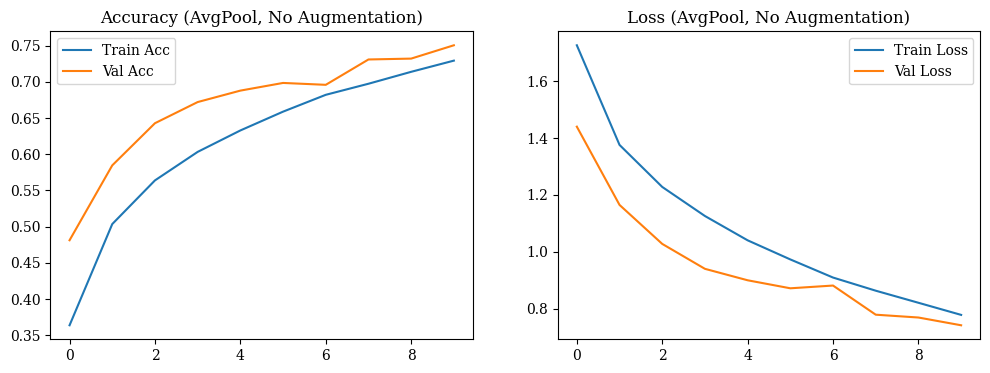

In [57]:
#Avg Pool No Data Aug Model
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom, Input

model_avgpool_no_aug = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    AveragePooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    AveragePooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    AveragePooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

model_avgpool_no_aug.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

history_avgpool_no_aug = model_avgpool_no_aug.fit(
    x_train, y_train_onehot,
    batch_size=32,
    epochs=10,
    validation_split=0.1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_avgpool_no_aug.history["accuracy"], label="Train Acc")
plt.plot(history_avgpool_no_aug.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy (AvgPool, No Augmentation)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_avgpool_no_aug.history["loss"], label="Train Loss")
plt.plot(history_avgpool_no_aug.history["val_loss"], label="Val Loss")
plt.title("Loss (AvgPool, No Augmentation)")
plt.legend()
plt.show()

In [58]:
#Avg Pool + Data Aug
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
], name="data_augmentation")

model = Sequential([
    Input(shape=(32, 32, 3)),
    data_augmentation,

    Conv2D(32, (3, 3), activation="relu", padding="same"),
    AveragePooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu", padding="same"),
    AveragePooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu", padding="same"),
    AveragePooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_14            │ (None, 4, 4, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.3426 - loss: 1.8029 - val_accuracy: 0.4652 - val_loss: 1.4377
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4444 - loss: 1.5346 - val_accuracy: 0.5234 - val_loss: 1.2993
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4900 - loss: 1.4218 - val_accuracy: 0.5670 - val_loss: 1.2017
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5223 - loss: 1.3386 - val_accuracy: 0.6128 - val_loss: 1.1042
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5430 - loss: 1.2849 - val_accuracy: 0.6266 - val_loss: 1.0342
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5620 - loss: 1.2394 - val_accuracy: 0.6336 - val_loss: 1.0438
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5784 - loss: 1.1967 - val_accuracy: 0.6602 - val_loss: 0.9770
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.5892 - loss: 1

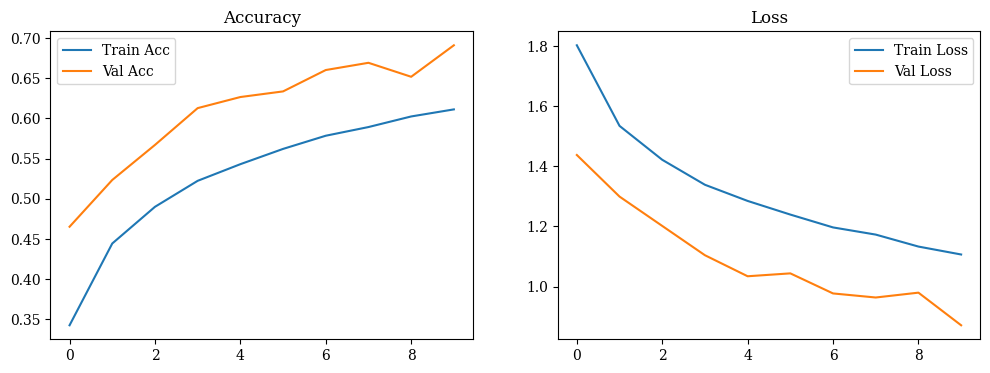

In [59]:
history = model.fit(x_train, y_train_onehot, batch_size=32, epochs=10, validation_split=0.1)

plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()
plt.show()